# Indian City Climate — Descriptive Analysis

A purely **exploratory** pass over `Indian_Climate_Dataset_2024_2025.csv`:
7,310 daily observations across 10 Indian cities, 2024–2025, with nine weather
channels each.

No models, no forecasting. The question here is the one you ask before any of
that: **what is actually in this data?**

---

### How to read the conclusions in this notebook

Descriptive statistics compute happily on any numbers. A mean is a mean whether
the values were measured by a weather station or drawn from a random number
generator. So alongside each result this notebook asks a second question —
*is this value physically plausible for an Indian city?* — and flags the answer
explicitly.

That check turns out to matter. Sections marked **⚠️** are where the observed
statistic contradicts well-established Indian climatology.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from tsa_temperature.data import load_panel
from tsa_temperature import analysis as an, plots

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110

panel = load_panel()
df = panel.frame
df.head()

,date,city,state,temp_max,temp_min,temp_avg,humidity,rainfall,wind_speed,aqi,aqi_category,pressure,cloud_cover
0,2024-01-01,Ahmedabad,Gujarat,32.8,25.1,28.9,83.9,0.0,5.2,345,Very Poor,1018.1,12.1
1,2024-01-02,Ahmedabad,Gujarat,32.4,21.0,26.7,71.2,5.4,9.4,223,Poor,996.5,8.9
2,2024-01-03,Ahmedabad,Gujarat,37.3,22.4,29.8,39.1,5.2,18.0,131,Moderate,1014.6,39.2
3,2024-01-04,Ahmedabad,Gujarat,32.8,21.3,27.0,59.8,0.0,24.1,61,Satisfactory,1021.7,23.6
4,2024-01-05,Ahmedabad,Gujarat,27.4,15.9,21.6,78.5,0.0,8.6,338,Very Poor,1020.4,26.2


## 1. Dataset profile

Size, coverage and completeness before anything else.

In [2]:
an.dataset_profile(df)

rows                              7310
columns                             13
cities                              10
states                              10
start                       2024-01-01
end                         2025-12-31
days_spanned                       731
days_per_city                      731
expected_rows                     7310
completeness_pct                 100.0
duplicate_city_date_rows             0
total_missing_cells                  0
memory_mb                         1.92
Name: value, dtype: object

A complete, gap-free panel: every one of the 10 cities has all 731 days, no
duplicate `(city, date)` pairs, no missing cells. Whatever else is true, the
data is *structurally* clean — which is worth knowing, because it means nothing
below is an artifact of missing-value handling.

In [3]:
an.column_inventory(df)

,dtype,n_missing,pct_missing,n_unique,min,max
column,,,,,,
date,datetime64[ns],0,0.0,731,,
city,object,0,0.0,10,,
state,object,0,0.0,10,,
temp_max,float64,0,0.0,201,25.0,45.0
temp_min,float64,0,0.0,296,10.1,39.8
temp_avg,float64,0,0.0,247,17.6,42.3
humidity,float64,0,0.0,651,30.0,95.0
rainfall,float64,0,0.0,659,0.0,79.9
wind_speed,float64,0,0.0,231,2.0,25.0


## 2. Distributions

`describe()` gives location and spread. The more diagnostic numbers are the
**shape** statistics — skewness and excess kurtosis.

Useful reference points:

| Distribution | skew | excess kurtosis |
|---|---|---|
| Normal | 0 | 0 |
| **Uniform** | 0 | **−1.2** |
| Daily temperature in a seasonal climate | ~0 | −0.5 to −1.0, usually **bimodal** |

In [4]:
an.numeric_summary(df)

,n,mean,std,min,q25,median,q75,max,iqr,cv_pct,skew,excess_kurtosis
variable,,,,,,,,,,,,
temp_avg,7310,29.980,5.967,17.6,25.000,30.0,35.0,42.3,10.000,19.902,0.003,-1.059
temp_max,7310,34.952,5.781,25.0,30.000,34.9,40.0,45.0,10.000,16.541,0.014,-1.204
temp_min,7310,25.006,6.476,10.1,19.900,25.0,30.0,39.8,10.100,25.898,-0.002,-0.807
humidity,7310,62.654,18.680,30.0,46.400,62.7,78.7,95.0,32.300,29.815,-0.005,-1.189
rainfall,7310,8.231,17.758,0.0,0.000,0.0,6.3,79.9,6.300,215.740,2.545,5.487
wind_speed,7310,13.523,6.563,2.0,7.900,13.5,19.1,25.0,11.200,48.531,-0.000,-1.180
aqi,7310,193.760,89.183,40.0,116.000,194.0,270.0,349.0,154.000,46.027,0.010,-1.201
pressure,7310,1007.359,10.110,990.0,998.700,1007.3,1016.2,1025.0,17.500,1.004,0.005,-1.194
cloud_cover,7310,52.630,27.328,5.0,28.925,52.7,76.2,100.0,47.275,51.924,-0.007,-1.195


⚠️ **Every channel except rainfall sits at excess kurtosis ≈ −1.06 to −1.20** —
the signature of a uniform distribution. Temperature, humidity, wind speed, AQI,
pressure and cloud cover all show it.

Rainfall is the exception (skew 2.5, kurtosis 5.5), which is genuinely
rain-like: mostly zeros with a long right tail.

Formal tests on the temperature channel:

In [5]:
an.distribution_shape_by_city(df)

,n,mean,std,skew,excess_kurtosis,p_normal,p_uniform,closest_shape
Ahmedabad,731,30.144,6.087,-0.02,-1.097,0.0,0.0209,uniform
Bengaluru,731,30.08,5.998,-0.024,-1.056,0.0,0.0001,uniform
Bhopal,731,29.965,5.909,0.005,-1.059,0.0,0.0,uniform
Chennai,731,29.831,5.843,0.032,-0.993,0.0,0.0002,uniform
Delhi,731,30.074,5.873,-0.004,-1.037,0.0,0.0005,uniform
Hyderabad,731,29.978,5.998,0.028,-1.045,0.0,0.0028,uniform
Jaipur,731,29.646,6.041,0.07,-1.031,0.0,0.0003,uniform
Kolkata,731,30.413,5.881,-0.127,-0.98,0.0,0.0,uniform
Lucknow,731,29.899,6.028,0.07,-1.131,0.0,0.0003,uniform
Mumbai,731,29.771,6.006,0.003,-1.117,0.0,0.0,uniform


Every city returns `closest_shape = uniform`, with normality decisively
rejected. Temperature is not uniformly distributed anywhere on Earth — real
daily temperature clusters around seasonal modes.

The histograms make it visible. The dashed line is a uniform density fitted to
each city's range; the solid curve is the best-fit normal.

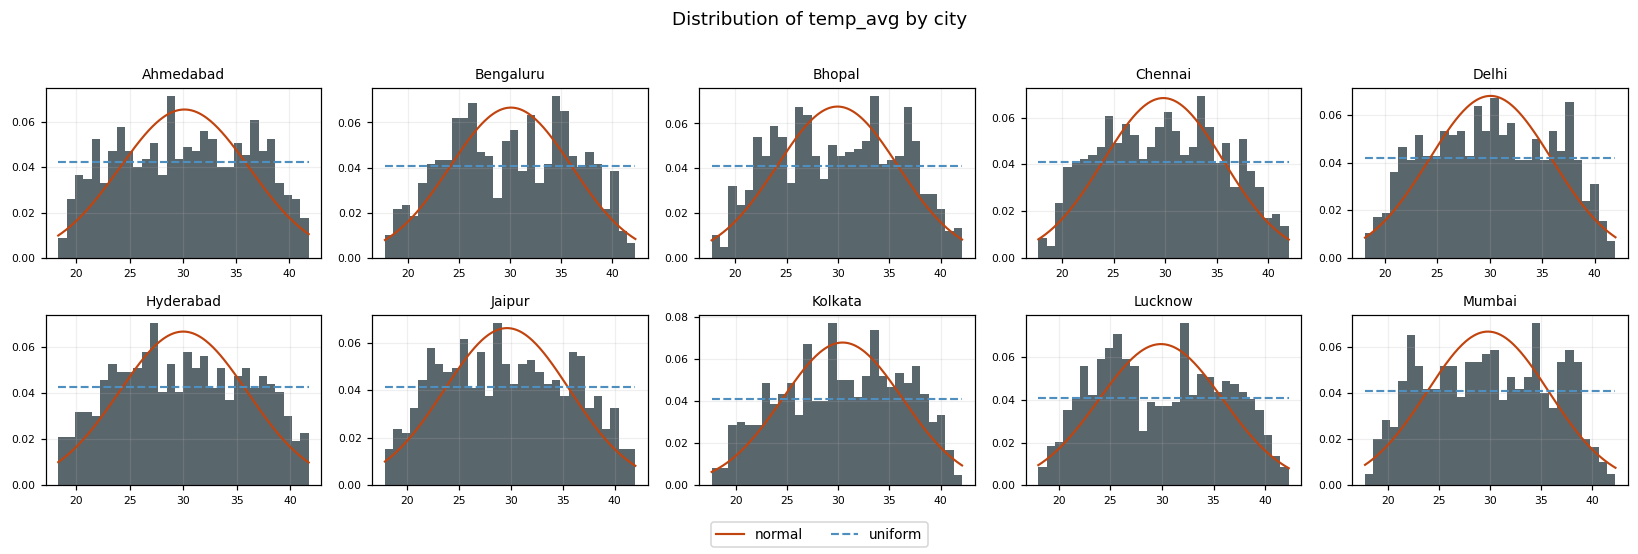

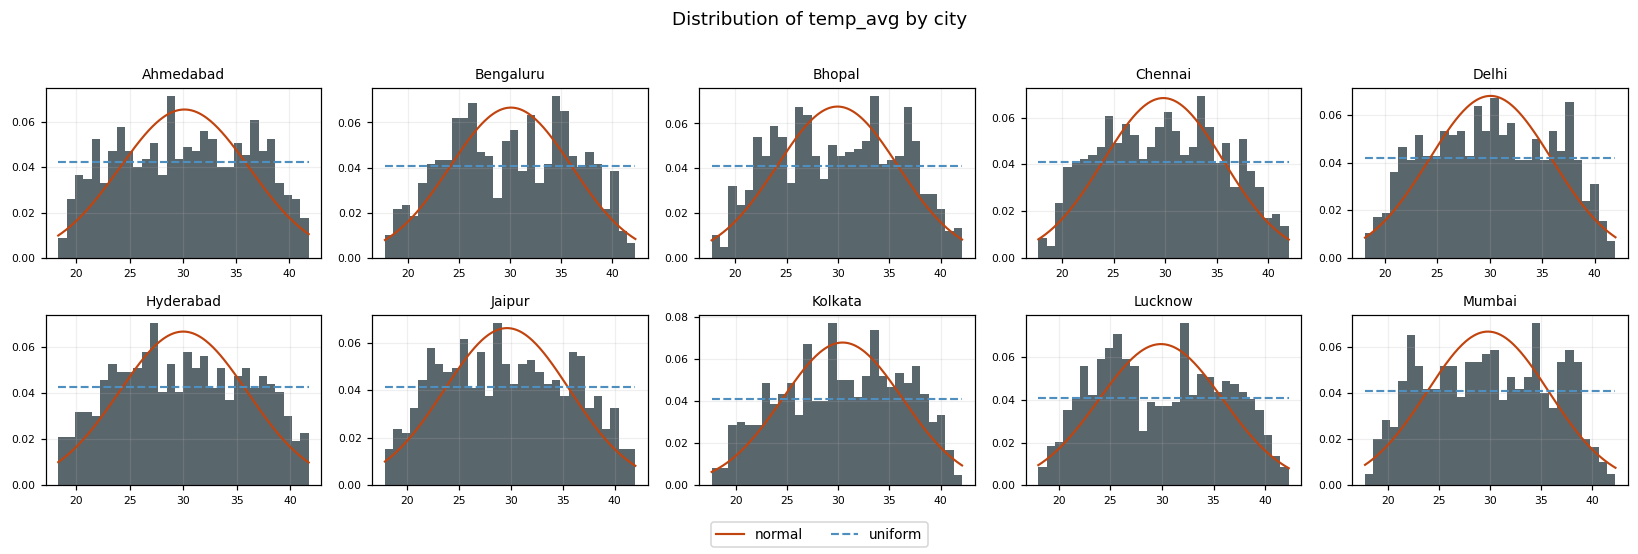

In [6]:
plots.plot_distribution_grid(df, column="temp_avg")

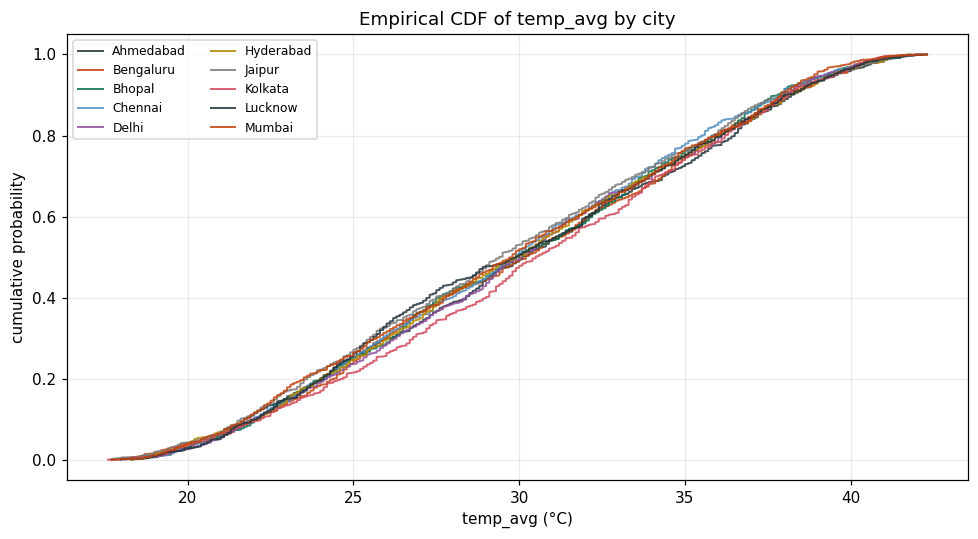

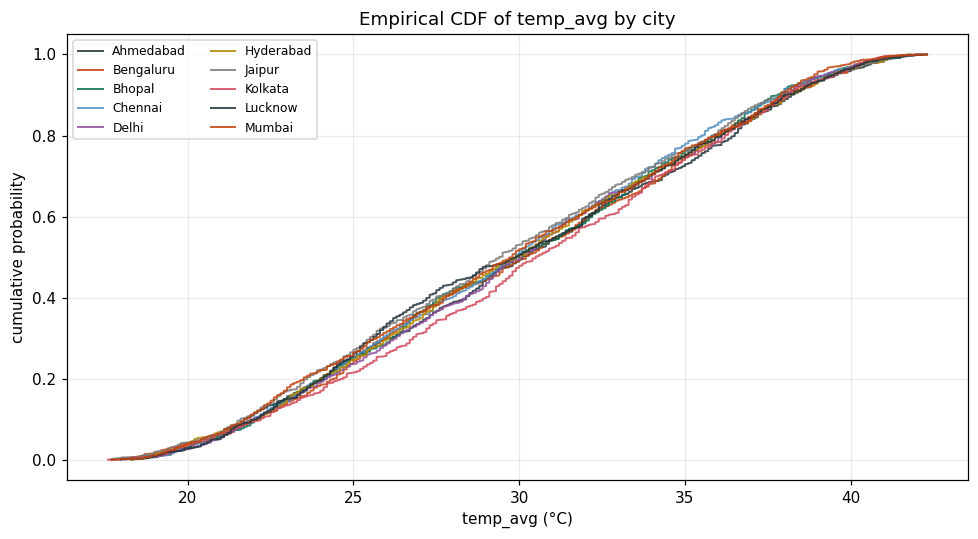

In [7]:
plots.plot_ecdf(df, column="temp_avg")

Ten near-perfect straight diagonals. A cumulative distribution is a straight
line only when the underlying values are uniform.

## 3. City profiles

Per-city location, spread and seasonal behaviour.

In [8]:
profile = an.city_profile(df)
profile

,state,mean_temp,std_temp,min_temp,max_temp,observed_range,seasonal_amplitude,hottest_month,coldest_month,mean_diurnal_range
city,,,,,,,,,,
Kolkata,West Bengal,30.41,5.88,17.6,42.1,24.5,3.14,Nov,Dec,9.92
Ahmedabad,Gujarat,30.14,6.09,18.3,41.8,23.5,3.62,Apr,Feb,9.79
Bengaluru,Karnataka,30.08,6.00,17.7,42.3,24.6,1.74,Jan,Feb,10.05
Delhi,Delhi,30.07,5.87,18.1,42.0,23.9,2.64,Nov,Dec,9.89
Hyderabad,Telangana,29.98,6.00,18.3,41.7,23.4,1.51,Jun,Jan,10.04
Bhopal,Madhya Pradesh,29.96,5.91,17.7,42.1,24.4,3.56,May,Feb,9.90
Lucknow,Uttar Pradesh,29.90,6.03,18.0,42.3,24.3,3.16,Jun,Jan,10.02
Chennai,Tamil Nadu,29.83,5.84,17.7,42.0,24.3,1.65,Aug,May,9.91
Mumbai,Maharashtra,29.77,6.01,17.7,42.3,24.6,2.01,May,Dec,9.91


Two things stand out.

**The cities are nearly indistinguishable.** Mean temperature spans 29.65 °C to
30.41 °C — a total spread of 0.76 °C across the whole country. Standard
deviations sit between 5.87 and 6.09.

⚠️ **`seasonal_amplitude` — the gap between the hottest and coldest monthly
mean — is 1.5 to 3.6 °C for every city.** Delhi's real figure is around 20 °C.

`hottest_month` and `coldest_month` are also incoherent: Bengaluru peaks in
January, Kolkata in November, Delhi in November. Northern India peaks in
May–June without exception.

In [9]:
plaus = an.climatology_plausibility(df)
plaus

,observed_mean,reference_mean,mean_gap,observed_amplitude,reference_amplitude,amplitude_ratio,eta_squared,plausible
city,,,,,,,,
Kolkata,30.41,26.5,3.91,3.14,14.0,0.224,0.0264,False
Ahmedabad,30.14,27.5,2.64,3.62,16.0,0.226,0.0248,False
Bengaluru,30.08,24.0,6.08,1.74,6.0,0.290,0.0072,False
Delhi,30.07,25.0,5.07,2.64,20.0,0.132,0.0166,False
Hyderabad,29.98,26.5,3.48,1.51,10.0,0.151,0.0068,False
Bhopal,29.96,25.0,4.96,3.56,16.0,0.223,0.0245,False
Lucknow,29.90,25.5,4.40,3.16,20.0,0.158,0.0241,False
Chennai,29.83,28.5,1.33,1.65,7.0,0.236,0.0080,False
Mumbai,29.77,27.5,2.27,2.01,6.0,0.335,0.0090,False


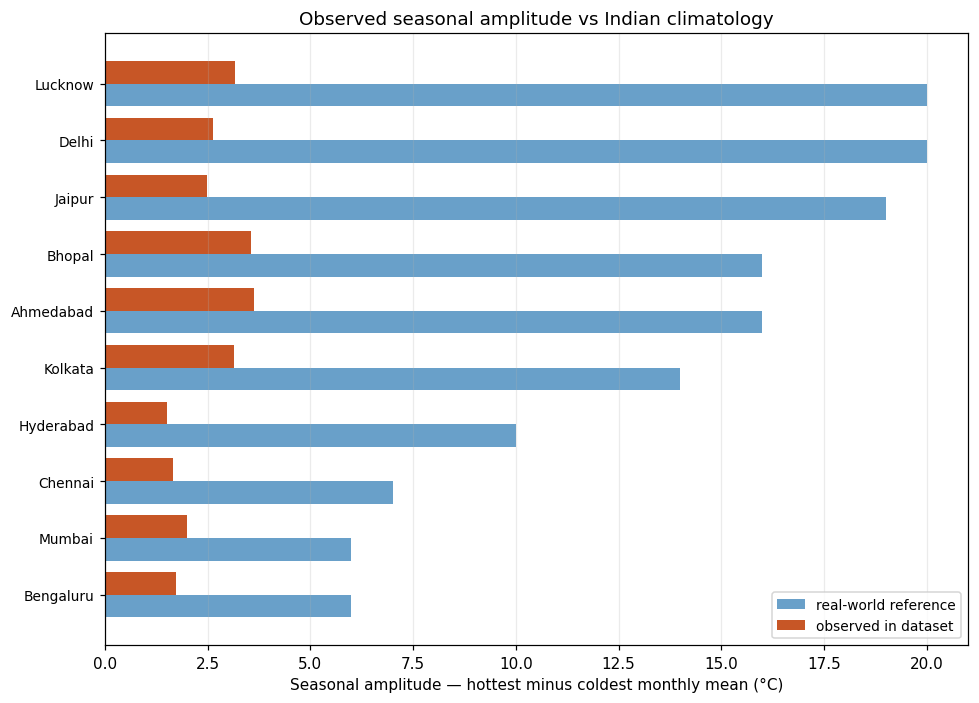

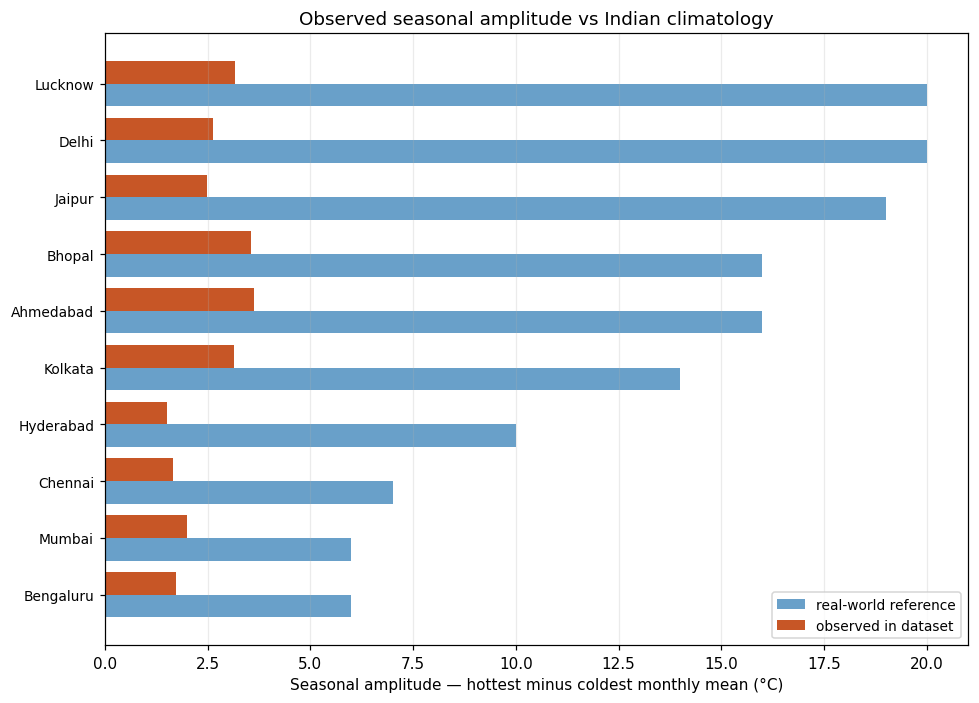

In [10]:
plots.plot_observed_vs_reference(plaus)

⚠️ Not one city clears the plausibility check. Observed seasonal amplitude runs
**13–34% of the real value**, and the gap is worst exactly where it should be
largest — Delhi (0.13), Jaipur (0.13), Lucknow (0.16), all strongly continental
climates with 19–20 °C real annual swings.

Coastal Mumbai and Chennai score highest simply because their genuine amplitude
is smallest, so there is less to miss.

## 4. Temporal structure

If a temperature dataset has one dominant pattern, it is the annual cycle.

In [11]:
an.monthly_profile(df, city="Delhi")

,n,mean,std,min,median,max,spread_from_annual_mean
month_name,,,,,,,
Jan,62,30.00,5.65,18.1,30.50,39.4,-0.07
Feb,57,29.32,6.23,19.1,29.10,40.9,-0.75
Mar,62,30.51,5.73,18.8,30.80,40.7,0.44
Apr,60,30.81,7.01,19.4,30.90,42.0,0.74
May,62,29.55,5.45,18.7,30.00,40.0,-0.52
Jun,60,30.82,5.68,19.3,31.00,41.3,0.75
Jul,62,29.73,5.73,18.2,29.95,40.7,-0.34
Aug,62,30.05,5.81,19.5,29.55,41.1,-0.02
Sep,60,29.98,5.94,19.1,30.20,38.7,-0.09


Delhi, month by month: every monthly mean lands between 28.3 °C and 30.9 °C.
December is the coldest month at 28.3 °C.

For reference, Delhi's actual January mean is about 14 °C and June about 34 °C.

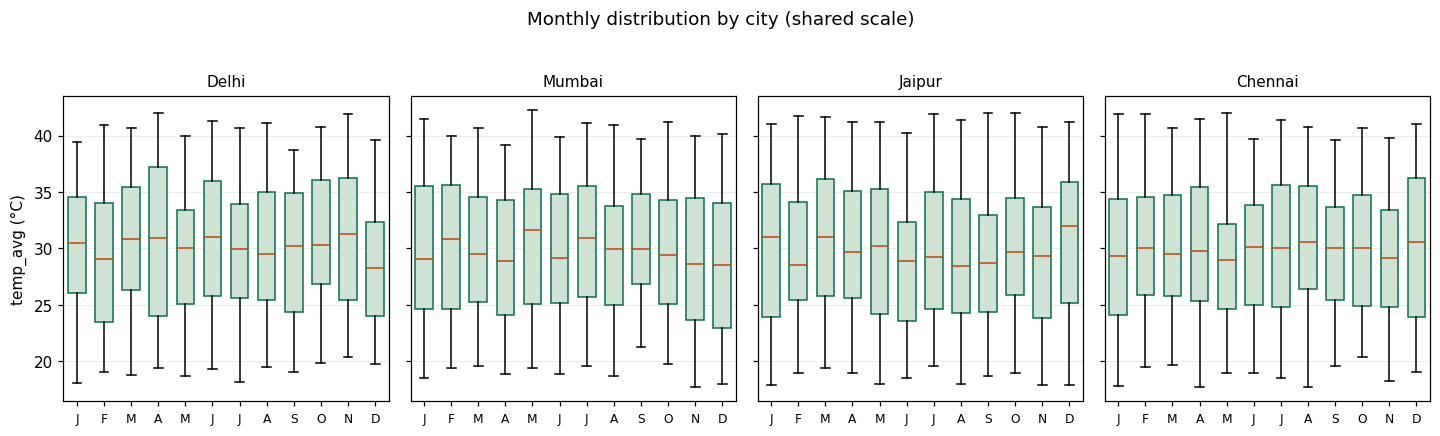

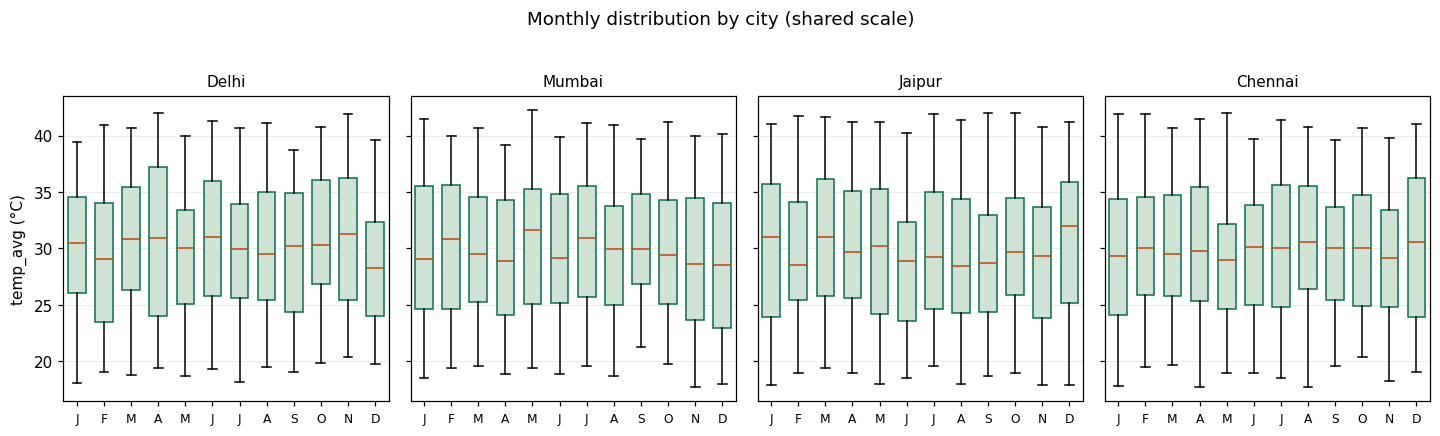

In [12]:
plots.plot_monthly_boxplots(df, cities=["Delhi", "Mumbai", "Jaipur", "Chennai"])

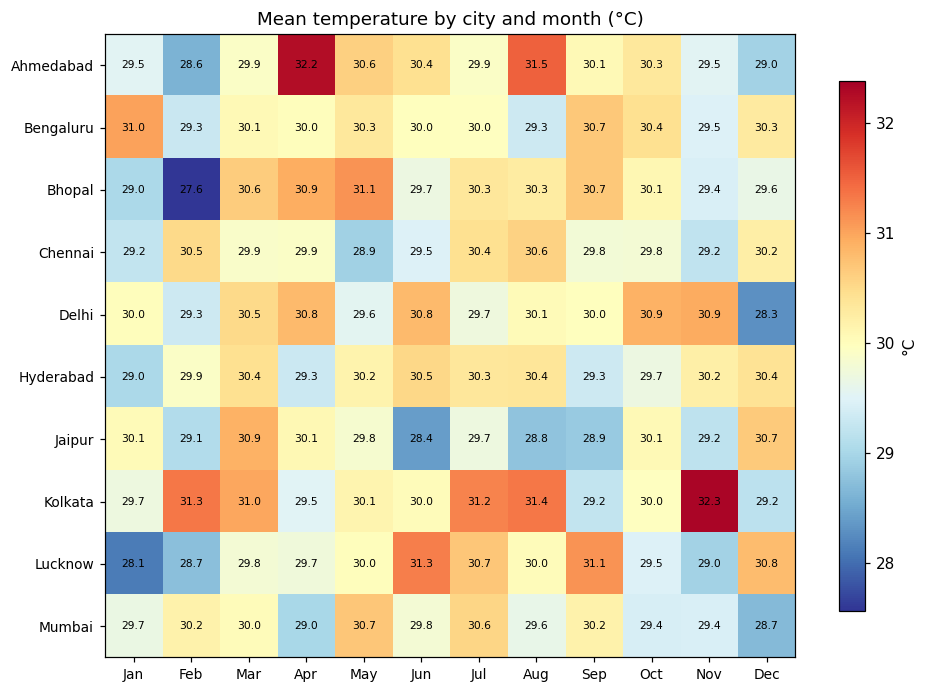

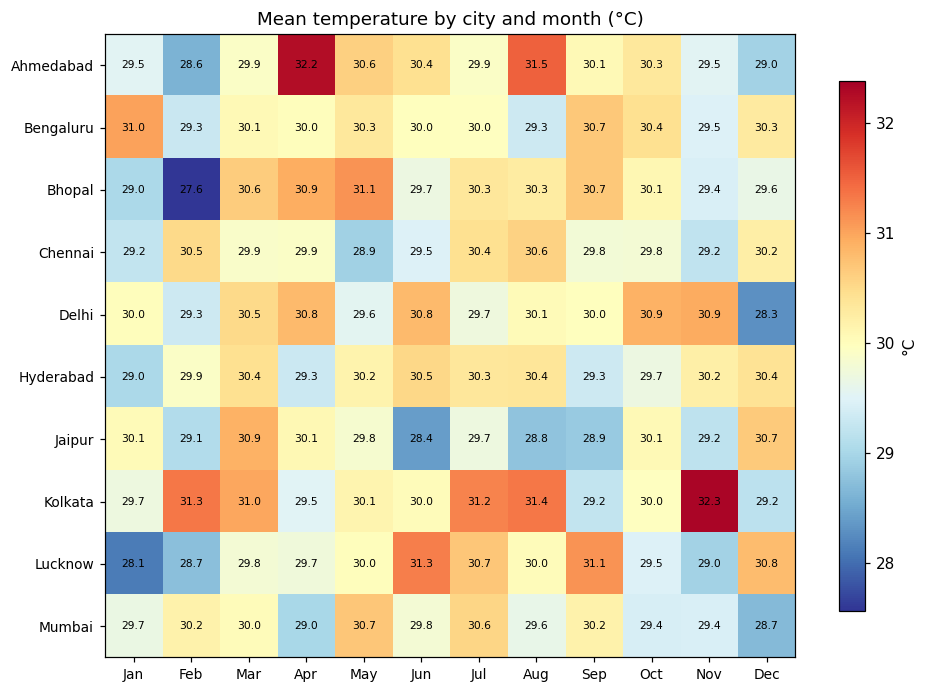

In [13]:
month_matrix = an.city_month_matrix(df)
plots.plot_city_month_heatmap(month_matrix, "Mean temperature by city and month (°C)")

The heatmap is the clearest single view. A real version of this chart is
banded — cool blues on the left and right, hot reds through the middle columns,
with northern cities showing far stronger contrast than coastal ones. Here the
colour is scattered at random, because the variation shown is sampling noise
around a constant.

In [14]:
an.monthly_variation_summary(df)

,monthly_mean_range,eta_squared,variance_explained_pct
city,,,
Kolkata,3.14,0.0264,2.6
Ahmedabad,3.62,0.0248,2.5
Bhopal,3.56,0.0245,2.4
Lucknow,3.16,0.0241,2.4
Delhi,2.64,0.0166,1.7
Jaipur,2.48,0.0149,1.5
Mumbai,2.01,0.0090,0.9
Chennai,1.65,0.0080,0.8
Bengaluru,1.74,0.0072,0.7


⚠️ `eta_squared` is the share of each city's temperature variance explained by
month-of-year. Here it ranges from **0.7% to 2.6%**.

In real Indian data, month-of-year explains **50–85%** of daily temperature
variance. It is by far the dominant factor. Values below 3% mean the calendar
carries essentially no information about temperature.

In [15]:
an.seasonal_profile(df)

,n,mean,std,min,max
season,,,,,
Winter,1810,29.57,6.00,17.6,42.3
Pre-monsoon,1840,30.20,5.91,17.7,42.3
Monsoon,2440,30.13,5.99,17.7,42.0
Post-monsoon,1220,29.95,5.93,17.7,42.1


Grouped into the four IMD seasons, the means are 29.57 / 30.20 / 30.13 /
29.95 °C. Winter and pre-monsoon differ by 0.63 °C. The real difference across
northern India is well over 15 °C.

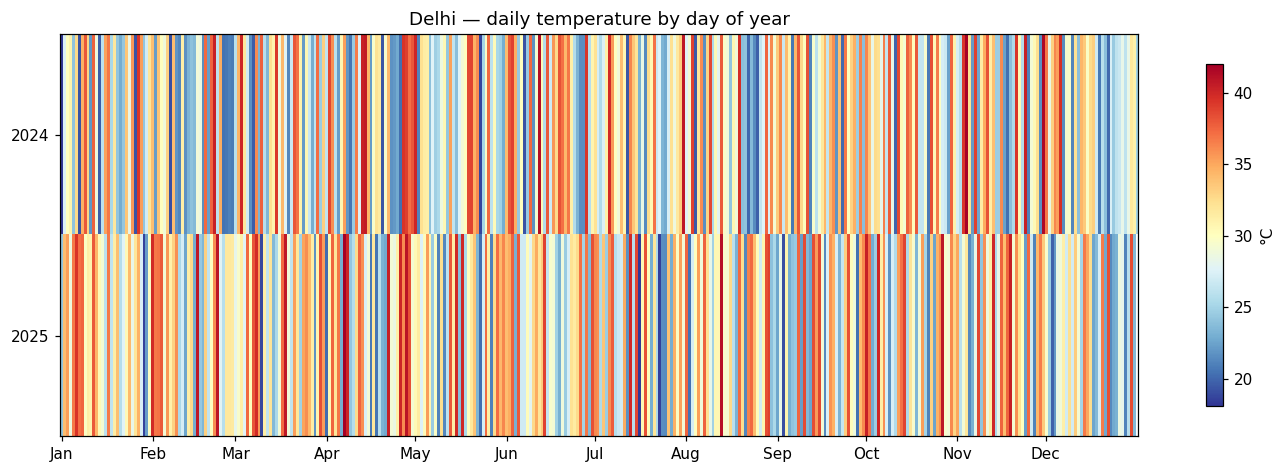

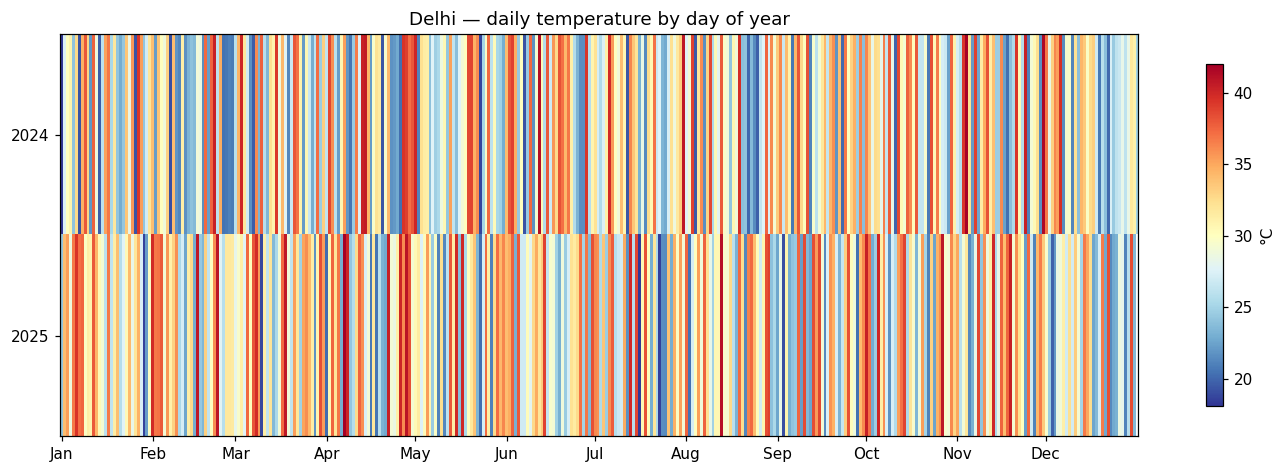

In [16]:
plots.plot_calendar_heatmap(panel.city_series("Delhi"), "Delhi — daily temperature by day of year")

Two years side by side. Real climate data produces horizontal banding: both
rows cool at the edges and hot through the middle, and the two years look alike
because the seasonal cycle repeats. Here each row is random static, and the two
rows are unrelated.

## 5. Diurnal range

The daily swing between maximum and minimum. Physically this narrows under
cloud and humidity — clear dry air radiates heat away overnight, cloud traps
it. It is one of the most reliable relationships in surface meteorology.

In [17]:
an.diurnal_range_profile(df)

,mean,std,min,max,Winter,Pre-monsoon,Monsoon,Post-monsoon,corr_with_cloud
city,,,,,,,,,
Bengaluru,10.05,2.88,5.0,15.0,9.81,9.86,10.18,10.42,-0.040
Hyderabad,10.04,2.90,5.0,15.0,10.28,10.19,9.73,10.09,0.030
Jaipur,10.03,2.92,5.0,15.0,9.78,9.84,10.22,10.30,0.028
Lucknow,10.02,2.91,5.0,15.0,9.74,9.89,10.14,10.39,0.029
Kolkata,9.92,2.83,5.0,15.0,10.14,9.54,10.03,9.94,0.105
Chennai,9.91,2.83,5.0,15.0,9.80,10.06,9.85,9.95,0.056
Mumbai,9.91,2.90,5.0,15.0,10.07,9.72,10.02,9.76,-0.011
Bhopal,9.90,2.90,5.0,15.0,9.98,9.54,10.06,10.03,-0.003
Delhi,9.89,2.91,5.0,15.0,9.82,10.06,9.83,9.85,0.018


⚠️ Every city reports a mean diurnal range of **9.79–10.05 °C** — a spread of
0.26 °C across desert Jaipur and coastal Mumbai. In reality Jaipur's pre-monsoon
swing exceeds 15 °C while Mumbai's stays near 6 °C.

The seasonal columns are equally flat, and `corr_with_cloud` sits between −0.04
and +0.11 where a clear negative relationship should appear.

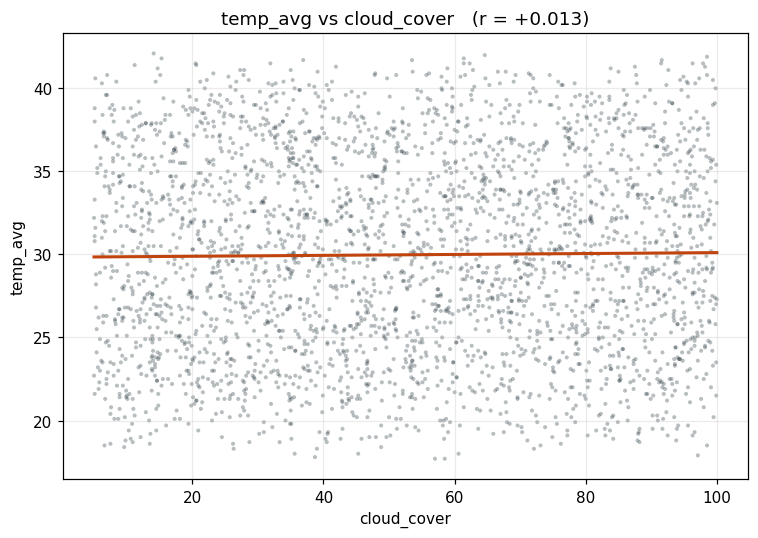

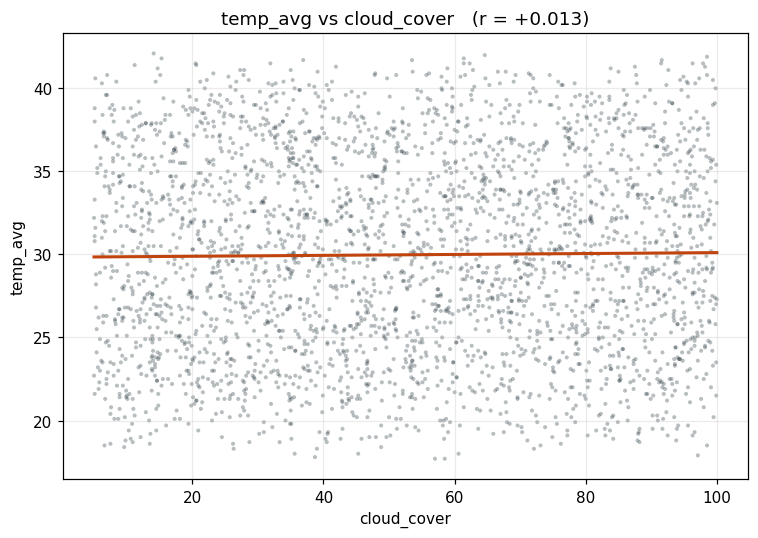

In [18]:
plots.plot_scatter_relationship(df, "cloud_cover", "temp_avg")

## 6. Extremes

Counts of hot and cold days, and — more informative — whether they *cluster*.

In [19]:
an.extreme_day_counts(df, hot_threshold=35.0, cold_threshold=15.0)

,n_days,days_max_ge_35,pct_hot,days_min_le_15,pct_cold
city,,,,,
Kolkata,731,388,53.1,43,5.9
Ahmedabad,731,370,50.6,52,7.1
Delhi,731,369,50.5,44,6.0
Bengaluru,731,366,50.1,46,6.3
Bhopal,731,365,49.9,41,5.6
Hyderabad,731,362,49.5,49,6.7
Chennai,731,361,49.4,42,5.7
Mumbai,731,361,49.4,50,6.8
Lucknow,731,354,48.4,42,5.7


Roughly half of all days exceed 35 °C in every city, and the cold-day count is
near zero everywhere. Uniform values between ~25 and ~45 °C on the daily
maximum produce exactly this.

The more revealing question is whether hot days arrive in blocks. Real
heatwaves persist: a hot day makes the next day more likely to be hot.

In [20]:
an.heat_spell_summary(df, hot_threshold=35.0)

,n_hot_days,longest_hot_run,expected_run_if_independent,clustering
city,,,,
Ahmedabad,370,11,8.65,1.27
Kolkata,388,11,9.22,1.19
Chennai,361,10,8.38,1.19
Bhopal,365,8,8.50,0.94
Delhi,369,8,8.62,0.93
Hyderabad,362,8,8.41,0.95
Lucknow,354,8,8.18,0.98
Bengaluru,366,7,8.53,0.82
Mumbai,361,7,8.38,0.84


⚠️ `clustering` compares the longest observed hot streak against what
independent coin-flip days would produce at the same hot-day rate. **All ten
cities score 0.74–1.27, i.e. ≈ 1.0** — statistically indistinguishable from
independence.

Real Indian summers produce heatwave runs several times longer than chance.
Consecutive days here carry no relationship to each other.

## 7. Relationships between channels

Temperature against each of the other eight measurements, with p-values and a
Holm–Bonferroni correction for testing eight hypotheses at once.

In [21]:
an.correlation_with_significance(df)

,pearson_r,pearson_p,spearman_rho,spearman_p,n,holm_threshold,significant
variable,,,,,,,
temp_min,0.9764,0.00000,0.9769,0.00000,7310,0.006250,True
temp_max,0.9703,0.00000,0.9721,0.00000,7310,0.007143,True
rainfall,-0.0213,0.06800,-0.0076,0.51758,7310,0.008333,False
wind_speed,-0.0189,0.10663,-0.0187,0.10954,7310,0.010000,False
aqi,0.0118,0.31507,0.0111,0.34126,7310,0.012500,False
pressure,-0.0042,0.72041,-0.0046,0.69466,7310,0.016667,False
humidity,0.0038,0.74499,0.0037,0.75103,7310,0.025000,False
cloud_cover,-0.0031,0.79005,-0.0027,0.81424,7310,0.050000,False


⚠️ Only `temp_max` and `temp_min` are significant — and those are definitional,
since `temp_avg` is exactly their midpoint:

In [22]:
gap = (df["temp_avg"] - (df["temp_max"] + df["temp_min"]) / 2).abs()
print(f"max |temp_avg - (temp_max + temp_min)/2| = {gap.max():.3f} °C")
print(f"mean deviation                          = {gap.mean():.3f} °C  (rounding only)")

max |temp_avg - (temp_max + temp_min)/2| = 0.050 °C
mean deviation                          = 0.025 °C  (rounding only)


So the two "significant" correlations carry no independent information.

Every genuine covariate — humidity (r = 0.004), pressure (−0.004), cloud cover
(−0.003), AQI (0.012), wind (−0.019) — is indistinguishable from zero. In real
surface data, humidity and diurnal range correlate strongly, and pressure
carries a clear seasonal signature.

In [23]:
corr = an.channel_correlation_matrix(df)
corr

,temp_avg,temp_max,temp_min,humidity,rainfall,wind_speed,aqi,pressure,cloud_cover
temp_avg,1.000,0.970,0.976,0.004,-0.021,-0.019,0.012,-0.004,-0.003
temp_max,0.970,1.000,0.895,0.005,-0.018,-0.017,0.010,-0.002,0.003
temp_min,0.976,0.895,1.000,0.002,-0.023,-0.019,0.013,-0.006,-0.008
humidity,0.004,0.005,0.002,1.000,-0.004,-0.005,-0.008,0.001,0.029
rainfall,-0.021,-0.018,-0.023,-0.004,1.000,-0.012,0.002,0.001,0.008
wind_speed,-0.019,-0.017,-0.019,-0.005,-0.012,1.000,-0.011,0.005,-0.010
aqi,0.012,0.010,0.013,-0.008,0.002,-0.011,1.000,-0.005,-0.006
pressure,-0.004,-0.002,-0.006,0.001,0.001,0.005,-0.005,1.000,-0.002
cloud_cover,-0.003,0.003,-0.008,0.029,0.008,-0.010,-0.006,-0.002,1.000


## 8. Air quality

aqi_category,Good,Satisfactory,Moderate,Poor,Very Poor
city,,,,,
Ahmedabad,2.7,16.7,33.4,32.7,14.5
Bengaluru,3.1,17.0,33.8,30.5,15.6
Bhopal,3.0,15.0,31.5,30.8,19.7
Chennai,3.7,15.0,30.2,32.8,18.2
Delhi,3.3,16.0,33.8,31.2,15.7
Hyderabad,2.9,18.1,31.1,35.2,12.9
Jaipur,4.7,15.6,34.1,31.7,14.0
Kolkata,4.0,17.2,32.0,32.6,14.2
Lucknow,3.7,14.8,33.0,31.5,17.1


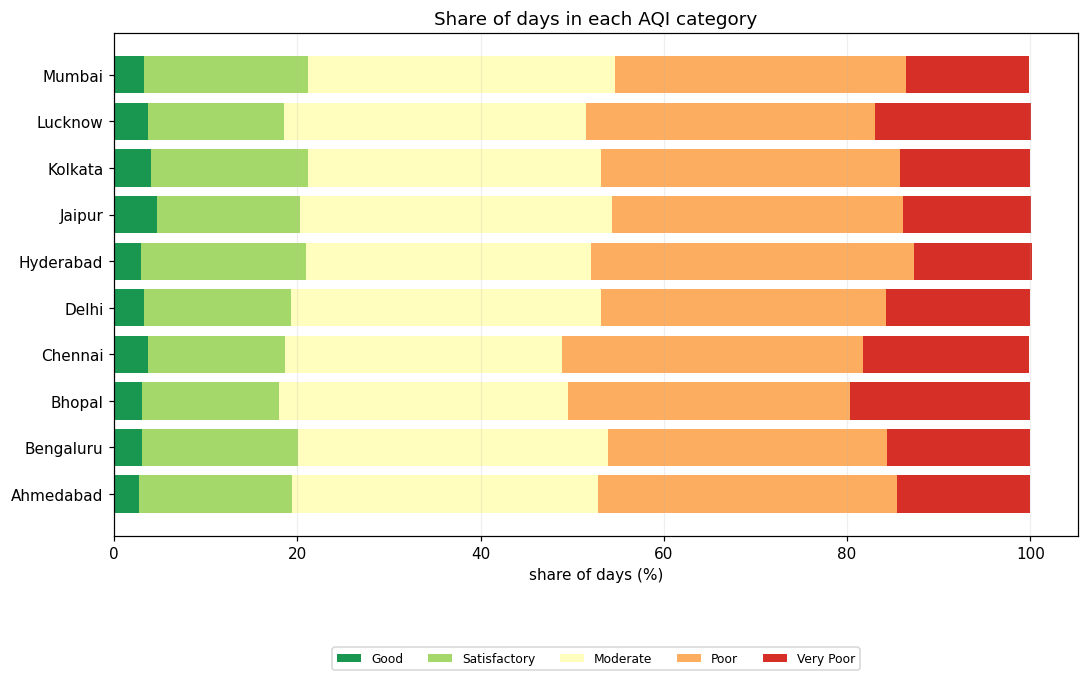

In [24]:
burden = an.aqi_category_burden(df)
plots.plot_stacked_shares(burden, "Share of days in each AQI category")
burden

In [25]:
an.aqi_seasonality(df)

season,Winter,Pre-monsoon,Monsoon,Post-monsoon,winter_minus_monsoon
city,,,,,
Hyderabad,202.3,191.9,190.2,183.4,12.1
Chennai,201.2,193.0,206.0,189.7,-4.8
Lucknow,199.2,186.6,203.6,201.4,-4.4
Ahmedabad,198.1,188.7,198.2,186.2,-0.1
Bhopal,195.7,199.4,207.3,198.8,-11.6
Jaipur,195.5,180.7,188.1,198.2,7.4
Kolkata,189.2,200.8,186.6,187.2,2.6
Mumbai,188.7,188.7,185.6,185.9,3.1
Delhi,186.1,185.7,207.8,192.0,-21.7


⚠️ North Indian AQI has a pronounced winter peak — cool stagnant air traps
particulates, and the monsoon scrubs them out. Delhi's winter mean routinely
runs 3–4× its monsoon mean.

Here `winter_minus_monsoon` ranges from +12 to −5 AQI points, with no
consistent direction across cities. The AQI values are drawn independently of
season.

## 9. Cross-city structure

Cities within one country share weather systems. A cold snap over the
Indo-Gangetic plain hits Delhi, Lucknow and Jaipur together.

In [26]:
city_corr = an.cross_city_correlation(df)
city_corr

city,Ahmedabad,Bengaluru,Bhopal,Chennai,Delhi,Hyderabad,Jaipur,Kolkata,Lucknow,Mumbai
city,,,,,,,,,,
Ahmedabad,1.000,0.037,0.033,0.015,0.003,0.067,-0.045,-0.031,0.018,0.022
Bengaluru,0.037,1.000,0.043,0.000,-0.008,-0.021,-0.070,0.025,-0.061,0.037
Bhopal,0.033,0.043,1.000,-0.055,-0.051,0.030,-0.102,-0.030,-0.032,-0.079
Chennai,0.015,0.000,-0.055,1.000,-0.001,-0.030,0.044,-0.015,0.002,-0.012
Delhi,0.003,-0.008,-0.051,-0.001,1.000,-0.013,-0.058,0.021,0.009,0.008
Hyderabad,0.067,-0.021,0.030,-0.030,-0.013,1.000,0.055,-0.004,-0.050,0.015
Jaipur,-0.045,-0.070,-0.102,0.044,-0.058,0.055,1.000,0.007,0.008,0.013
Kolkata,-0.031,0.025,-0.030,-0.015,0.021,-0.004,0.007,1.000,0.003,0.011
Lucknow,0.018,-0.061,-0.032,0.002,0.009,-0.050,0.008,0.003,1.000,-0.024


In [27]:
off_diag = city_corr.to_numpy()[np.triu_indices(len(city_corr), 1)]
print(f"mean pairwise correlation   : {off_diag.mean():+.4f}")
print(f"range                       : {off_diag.min():+.3f} to {off_diag.max():+.3f}")
print(f"pairs above 0.3             : {(off_diag > 0.3).sum()} of {len(off_diag)}")

mean pairwise correlation   : -0.0059
range                       : -0.102 to +0.067
pairs above 0.3             : 0 of 45


⚠️ Mean pairwise correlation is **−0.006**, and not a single pair exceeds 0.3.
Delhi and Lucknow — 500 km apart on the same plain, sharing the same weather
systems — are statistically independent in this dataset.

## 10. What the analysis shows

Every descriptive statistic computed cleanly. The dataset is complete,
well-formed and internally consistent. But eight independent lines of evidence
point the same way:

| # | Finding | Observed | Real Indian climate |
|---|---|---|---|
| 1 | Distribution shape | uniform (kurtosis ≈ −1.2) | seasonal modes |
| 2 | Seasonal amplitude | 1.5–3.6 °C | 6–20 °C |
| 3 | Variance explained by month | 0.7–2.6% | 50–85% |
| 4 | Coldest month | Dec, Feb, **Nov**, mixed | Dec–Jan consistently |
| 5 | Diurnal range spread across cities | 0.26 °C | ~9 °C |
| 6 | Heat-day clustering | ≈ 1.0 (independent) | strongly clustered |
| 7 | Covariate correlation with temp | \|r\| < 0.03 | humidity, cloud, pressure all strong |
| 8 | Cross-city correlation | −0.006 | 0.7–0.9 within a region |

Each one alone might be explained away. Together they only support one
conclusion: **the values are independently drawn from fixed ranges, not
measured.** The file is synthetic — plausible-looking column names and units
wrapped around random numbers.

### What that means in practice

- Descriptive summaries of this file are **arithmetically correct and
  substantively meaningless**. "Kolkata is India's warmest city at 30.4 °C" is
  a real computation on fake data.
- The same is true of any model fitted to it — see the companion notebook
  `temperature_timeseries_analysis.ipynb`, where every forecaster converges to
  the mean because there is nothing else to learn.
- Nothing here reflects on the analysis code. The pipeline is doing its job;
  the honest output is a negative result.

### To do this on real data

Drop a CSV with the same schema into `data/raw/` and re-run this notebook —
`config.COLUMN_RENAME` maps source headers to internal names. Good sources:

- **IMD** (India Meteorological Department) station data
- **NOAA GHCN-Daily** — free global daily station records
- **ERA5** reanalysis via the Copernicus Climate Data Store

Ten or more years would also make trend estimation and STL decomposition
viable, both of which two years cannot support.